# 02. Density-Based Learning: DBSCAN and HDBSCAN
**Algorithms implemented:** DBSCAN and HDBSCAN (hierarchical density-based clustering).

**Dataset:** Synthetic non-convex benchmark (moons + circles + blob + uniform noise).


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Density-based clustering algorithms + centroid baseline ----
from sklearn.cluster import DBSCAN, HDBSCAN, KMeans
# ---- Synthetic dataset generators for non-convex shapes ----
from sklearn.datasets import make_moons, make_blobs, make_circles
# ---- Nearest-neighbor search (used to pick epsilon) and scaling ----
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
# ---- Evaluation metrics ----
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Aesthetics setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("Density-based libraries loaded successfully!")


Density-based libraries loaded successfully!


In [2]:
# ---- Build a composite benchmark dataset with complex geometry ----
# Two interleaving half-moons (non-convex)
n_samples = 600
X_moons, y_moons = make_moons(n_samples=250, noise=0.06, random_state=42)
# Two concentric circles, shifted to the right so they do not overlap the moons
X_circle, y_circle = make_circles(n_samples=200, noise=0.04, factor=0.4, random_state=42)
X_circle = X_circle * 0.7 + np.array([2.2, 0.5])
# One sparse Gaussian blob above the moons
X_blob, y_blob = make_blobs(n_samples=100, centers=[[0.5, 2.0]], cluster_std=0.2, random_state=42)
# Uniform background noise (outliers) spanning the whole area
X_noise = np.random.uniform(low=[-1.5, -1.0], high=[3.2, 2.8], size=(50, 2))

# Stack all point groups into one feature matrix
X_raw = np.vstack([X_moons, X_circle, X_blob, X_noise])
# Ground-truth labels for benchmarking (noise points are marked with -1)
y_true = np.concatenate([y_moons, y_circle + 2, y_blob + 4, -np.ones(50, dtype=int)])

# Standardize so that epsilon (a distance threshold) has a comparable meaning in both axes
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# ---- Plot the raw benchmark to show the shapes/noise the algorithms must handle ----

print(f"Benchmark data: {X.shape[0]} points, {X.shape[1]} features")
print(f"Ground-truth groups: {len(set(y_true[y_true != -1]))} + noise")


Benchmark data: 600 points, 2 features
Ground-truth groups: 5 + noise


## 1. DBSCAN

### Step-by-Step Algorithm (DBSCAN)
1. **Parameters:** radius ε and minimum points MinPts (here 0.22 and 6).
2. For every point count its ε-neighborhood; points with ≥ MinPts neighbors become **core points**.
3. **Grow clusters:** connect core points that lie within ε of each other (density-reachability chain).
4. Attach border points (within ε of a core point) to that core's cluster.
5. Label every point that is neither core nor border as **noise (-1)**.
6. **Output:** arbitrary-shaped clusters + explicit noise labels. No K is required.

### How ε and MinPts Are Chosen Here
1. Set MinPts ≈ 2 x dimensions.
2. Plot the sorted distance to the MinPts-th neighbor and pick the "knee" as ε.
3. Fit DBSCAN and inspect cluster count, noise %, and agreement with the ground truth.

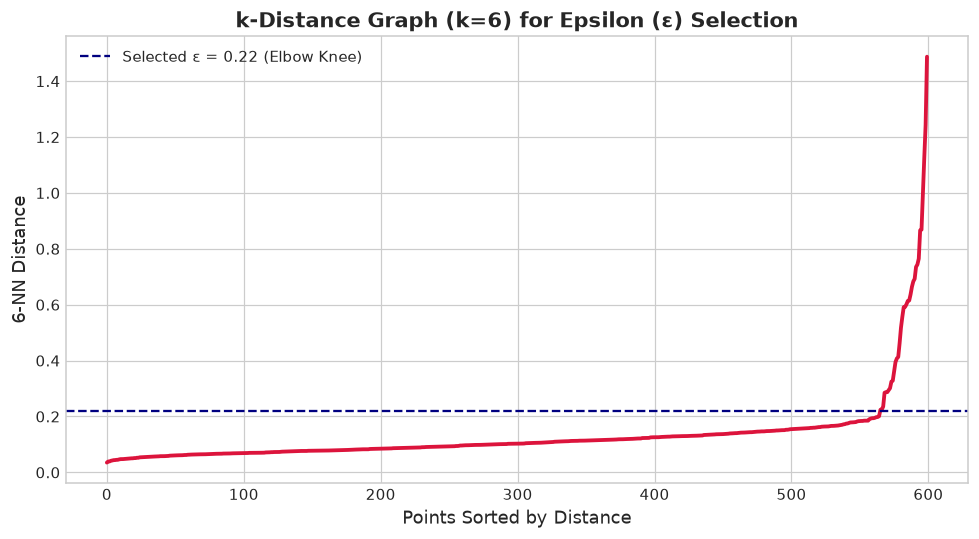

In [3]:
# ---- Choosing epsilon from the k-distance graph ----
# Heuristic: sort the distance of each point to its k-th nearest neighbor.
# The "knee" of the curve marks the transition from dense clusters to sparse noise,
# which is a good value for epsilon.
min_samples = 6  # MinPts rule of thumb: at least 2 * number of dimensions
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, indices = nbrs.kneighbors(X)     # distance to each point's k neighbors

k_distances = np.sort(distances[:, -1])     # k-th neighbor distance, sorted ascending

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='crimson', linewidth=2.5)
plt.title(f"k-Distance Graph (k={min_samples}) for Epsilon (ε) Selection", fontsize=14, fontweight='bold')
plt.xlabel("Points Sorted by Distance", fontsize=12)
plt.ylabel(f"{min_samples}-NN Distance", fontsize=12)
plt.axhline(y=0.22, color='navy', linestyle='--', label='Selected ε = 0.22 (Elbow Knee)')
plt.legend()
plt.tight_layout()
plt.show()


DBSCAN: 3 clusters, 28 noise points (4.7%)
DBSCAN Adjusted Rand Index vs ground truth: 0.4637


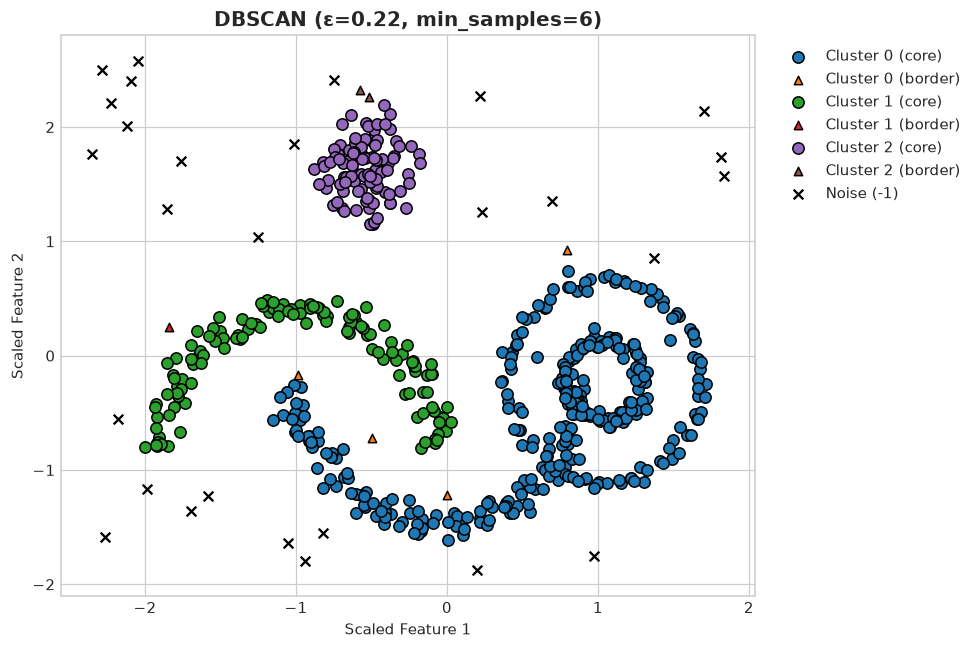

In [4]:
# ---- Fit DBSCAN and visualize the partition ----
eps_selected = 0.22
dbscan = DBSCAN(eps=eps_selected, min_samples=min_samples)
db_labels = dbscan.fit_predict(X)

# Core points are the density anchors; all remaining non-noise points are border points
core_samples_mask = np.zeros_like(db_labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = np.sum(db_labels == -1)
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise_db} noise points ({n_noise_db / len(X) * 100:.1f}%)")
print(f"DBSCAN Adjusted Rand Index vs ground truth: {adjusted_rand_score(y_true, db_labels):.4f}")

plt.figure(figsize=(9, 6))
for k in set(db_labels):
    mask = db_labels == k
    if k == -1:
        plt.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', s=40, label='Noise (-1)')
    else:
        plt.scatter(X[mask & core_samples_mask, 0], X[mask & core_samples_mask, 1], s=55, edgecolors='k', label=f'Cluster {k} (core)')
        plt.scatter(X[mask & ~core_samples_mask, 0], X[mask & ~core_samples_mask, 1], s=30, marker='^', edgecolors='k', label=f'Cluster {k} (border)')

plt.title(f"DBSCAN (ε={eps_selected}, min_samples={min_samples})", fontsize=13, fontweight='bold')
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 2. HDBSCAN

### Step-by-Step Algorithm (HDBSCAN)
1. Compute the **core distance** d_core(p) = distance from p to its k-th nearest neighbor.
2. Define the **mutual reachability distance**: d_mreach(a,b) = max{d_core(a), d_core(b), d(a,b)}.
3. Build a **minimum spanning tree** on the mutual-reachability graph.
4. Convert the MST into a **cluster hierarchy** and then into a **condensed tree** (cluster births/deaths).
5. Score each candidate cluster by **stability** S(C) = Σ (λ_p − λ_birth(C)) and keep the most stable ones.
6. **Output:** clusters of varying density, membership probabilities, and noise labels - with no global ε.

HDBSCAN: 3 clusters, 22 noise points (3.7%)
HDBSCAN Adjusted Rand Index vs ground truth: 0.4578


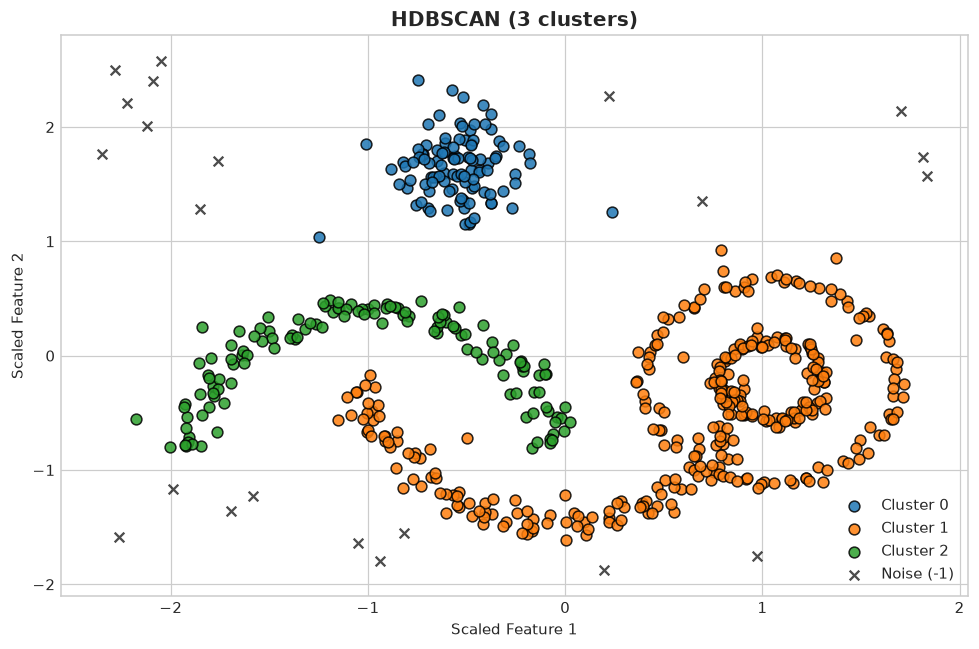

In [5]:
# ---- Fit HDBSCAN (no global epsilon needed) and visualize ----
hdb = HDBSCAN(min_cluster_size=15, min_samples=6, store_centers='centroid', copy=False)
hdb_labels = hdb.fit_predict(X)

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise_hdb = np.sum(hdb_labels == -1)
print(f"HDBSCAN: {n_clusters_hdb} clusters, {n_noise_hdb} noise points ({n_noise_hdb / len(X) * 100:.1f}%)")
print(f"HDBSCAN Adjusted Rand Index vs ground truth: {adjusted_rand_score(y_true, hdb_labels):.4f}")

plt.figure(figsize=(9, 6))
palette = sns.color_palette("tab10", max(n_clusters_hdb, 1))
for cluster_id in range(n_clusters_hdb):
    pts = X[hdb_labels == cluster_id]
    plt.scatter(pts[:, 0], pts[:, 1], color=palette[cluster_id], edgecolors='k', s=50, label=f'Cluster {cluster_id}', alpha=0.85)
noise_pts = X[hdb_labels == -1]
plt.scatter(noise_pts[:, 0], noise_pts[:, 1], color='black', marker='x', s=40, label='Noise (-1)', alpha=0.7)
plt.title(f"HDBSCAN ({n_clusters_hdb} clusters)", fontsize=13, fontweight='bold')
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Summary
Both density-based algorithms find arbitrary-shaped clusters and label sparse points
as noise; DBSCAN requires a global ε while HDBSCAN selects clusters across density levels.


In [6]:
# ---- Summary metrics (silhouette computed on non-noise points only) ----
def density_metrics(name, labels):
    mask = labels != -1
    sil = silhouette_score(X[mask], labels[mask]) if len(set(labels[mask])) > 1 else np.nan
    return {
        "Algorithm": name,
        "Clusters Found": len(set(labels)) - (1 if -1 in labels else 0),
        "Noise Points (%)": f"{np.sum(labels == -1) / len(labels) * 100:.1f}%",
        "Adjusted Rand Index": adjusted_rand_score(y_true, labels),
        "Silhouette (Non-Noise)": sil,
    }

comparison_table = pd.DataFrame([
    density_metrics("DBSCAN", db_labels),
    density_metrics("HDBSCAN", hdb_labels),
]).set_index("Algorithm")
display(comparison_table.style.highlight_max(subset=['Adjusted Rand Index', 'Silhouette (Non-Noise)'], color='lightgreen'))


,Clusters Found,Noise Points (%),Adjusted Rand Index,Silhouette (Non-Noise)
Algorithm,,,,
DBSCAN,3,4.7%,0.463683,0.434245
HDBSCAN,3,3.7%,0.457798,0.433431
